# Загрузка сцены

В этом блокноте объясняется, как загружать и редактировать сцены с помощью модуля трассировки лучей [RT](https://nvlabs.github.io/sionna/rt/index.html?spm=a2ty_o01.29997173.0.0.10605171KfB8Go) в Sionna. Вы научитесь: 
- Использовать функцию load_scene() для загрузки сцены с объединением объектов и без него
- Добавлять и удалять объекты из сцены
- Перемещать, вращать и масштабировать объекты в сцене

## Imports

In [20]:
import drjit as dr
import mitsuba as mi

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject

## Загрузка сцен и объединение объектов

Загрузка сцены в Sionna RT выполняется с помощью функции load_scene().

По умолчанию эта функция объединяет объекты, которые имеют схожие свойства, например, радиоматериалы. Это делается потому, что уменьшение количества объектов в сцене позволяет значительно ускорить трассировку лучей.

Объединение форм (shapes) можно отключить с помощью флага merge_shapes функции load_scene():

In [21]:
#scene = load_scene(sionna.rt.scene.simple_street_canyon,
#                   merge_shapes=False) # Disable merging of objects
scene = load_scene("room.xml", merge_shapes=False)

Теперь давайте выведем объекты, из которых состоит сцена, и их материалы. Мы видим, что объекты не были объединены, так как радиоматериалы встречаются в составе объектов несколько раз.

In [22]:
for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

elm__2         itu-concrete
elm__3         itu-concrete
elm__5         itu-glass
elm__7         itu-wood
elm__8         itu-wood
elm__9         itu-wood
elm__11        itu-metal
elm__12        itu-metal
elm__13        itu-metal


Теперь давайте перезагрузим сцену, включив объединение объектов:

In [23]:
scene = load_scene("room.xml", merge_shapes=True)

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

no-name-10     itu-concrete
elm__5         itu-glass
no-name-11     itu-metal
no-name-12     itu-wood


Мы видим, что объекты, имеющие одинаковые радиоматериалы, были объединены, так как каждый радиоматериал встречается в составе объектов только один раз.

Функция `load_scene()` также позволяет исключать определённые объекты из операции объединения с помощью регулярных выражений. Подробности о синтаксисе регулярных выражений см. в [документации Python](https://docs.python.org/3/library/re.html).

В качестве примера исключим из процесса объединения объекты с индексами меньше 3:

In [24]:
scene = load_scene("room.xml",
                   merge_shapes=True, # Enable merging of objects
                   merge_shapes_exclude_regex=r'building_[0-2]$') # Exclude from merging
                                                                  # buildings with indices < 3

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

no-name-13     itu-concrete
elm__5         itu-glass
no-name-14     itu-wood
no-name-15     itu-metal


*Мы видим, что объекты «building_1» и «building_2» не были объединены. В результате «building_5» также не был объединён, поскольку у него не осталось других объектов для слияния.

## Редактирование сцен

Давайте загрузим более сложную сцену и визуализируем её.

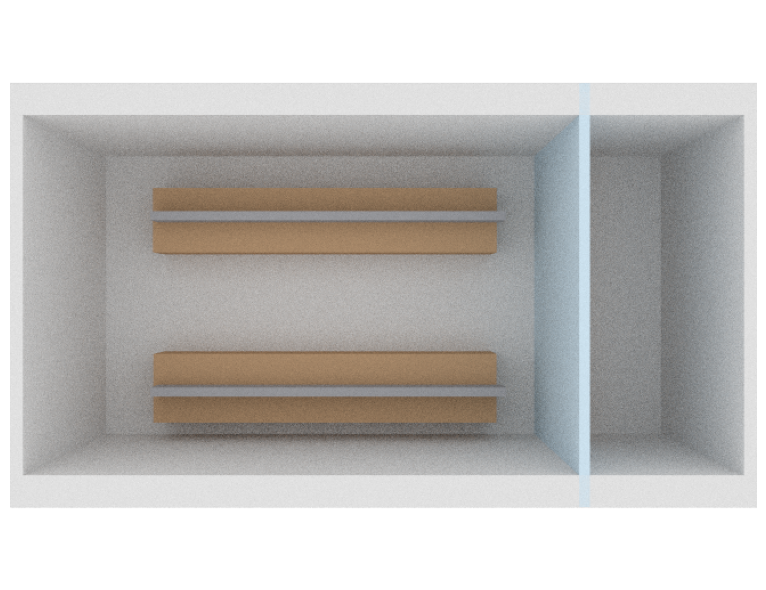

In [25]:
scene = load_scene("room.xml") # Objects are merged by default


#cam = Camera(position=[0.35,3.4,2],  look_at=[0,0,0])
cam = Camera(position=[0,0,10],  look_at=[0,0,0])
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Далее мы добавим несколько объектов в сцену.

В Sionna RT добавление объекта в сцену выполняется путем создания экземпляра нового [`SceneObject`](https://nvlabs.github.io/sionna/rt/api/scene_object.html) из mesh и последующего добавления этого объекта в сцену с помощью метода `Scene.add()`. При создании экземпляра `SceneObject` необходимо указать радиоматериал, из которого состоит объект.

В следующем примере мы добавим в ранее загруженную сцену автомобили, сделанные из металла.

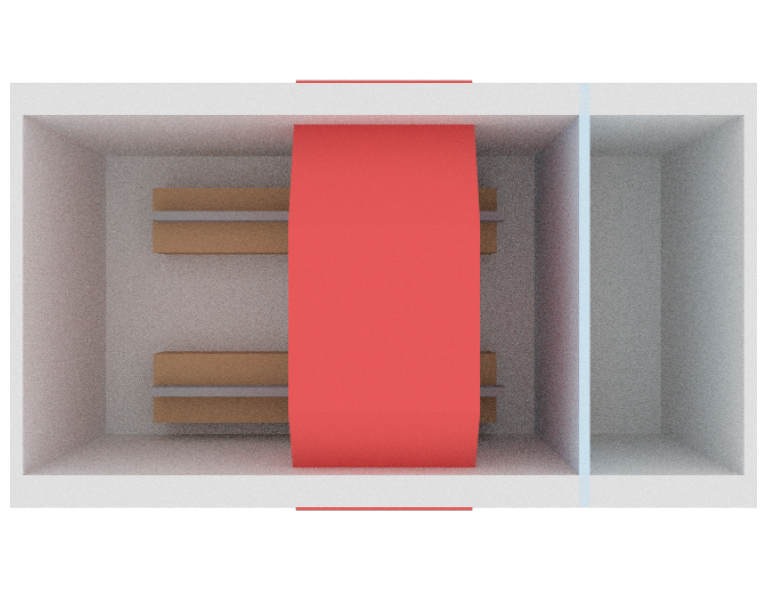

In [26]:
# Number of cars to add
num_cars = 10

# Radio material constituing the cars
# We use ITU metal, and use red color for visualization to
# make the cars easily discernible
car_material = ITURadioMaterial("car-material",
                                "metal",
                                thickness=0.01,
                                color=(0.8, 0.1, 0.1))

# Instantiate `num_cars` cars sharing the same mesh and material
cars = [SceneObject(fname=sionna.rt.scene.low_poly_car, # Simple mesh of a car
                    name=f"car-{i}",
                    radio_material=car_material)
        for i in range(num_cars)]

# Add the list of newly instantiated objects to the scene
scene.edit(add=cars)

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Мы видим красные автомобили в сцене, но поскольку все они находятся в одной и той же точке, создаётся впечатление, что был добавлен только один автомобиль. В следующей ячейке мы расставим автомобили в сцене, а также зададим их ориентацию.

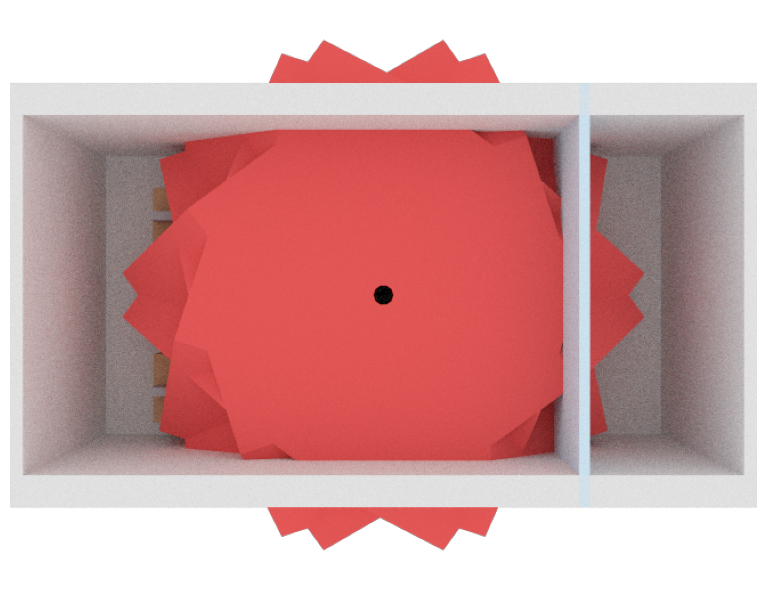

In [27]:
# Positions 
# Car are positioned in a circle around the central monument
# Center of the circle
c = mi.Point3f(0, 0, 0)
# Radius of the circle
r = 1
# Angles at which cars are positioned
thetas = dr.linspace(mi.Float, 0., dr.two_pi, num_cars, endpoint=False)
# Cars positions
cars_positions = c + mi.Point3f(dr.cos(thetas), dr.sin(thetas), 0.)*r

# Orientations
# Compute points the car "look-at" to set their orientation
d = dr.normalize(cars_positions - c)
# Tangent vector to the circle at the car position
look_at_dirs = mi.Vector3f(d.y, -d.x, 0.)
look_at_points = cars_positions + look_at_dirs

# Set the cars positions and orientations
for i in range(num_cars):
    cars[i].position = mi.Point3f(cars_positions.x[i], cars_positions.y[i], cars_positions.z[i])
    cars[i].look_at(mi.Point3f(look_at_points.x[i], look_at_points.y[i], look_at_points.z[i]))

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Objects can also be scaled. This is useful, for example, when the scale of the mesh from which the object is built does not suit the scene.

To illustrate this feature, let's scale the first car to be twice as large as the other cars.

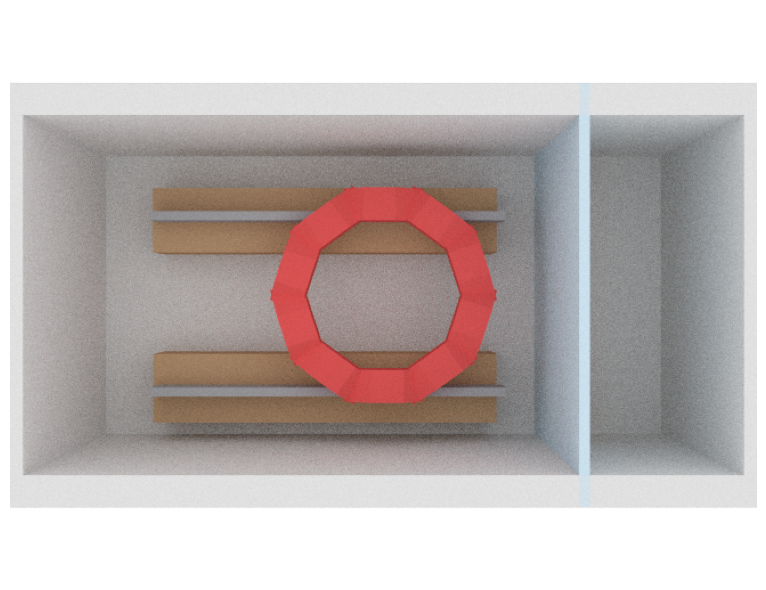

In [28]:
for i in range(len(cars)):
    cars[i].scaling = 0.2

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Finally, objects can be removed from the scene using the `Scene.edit()` function.

To illustrate this, let's remove the last car we have added.

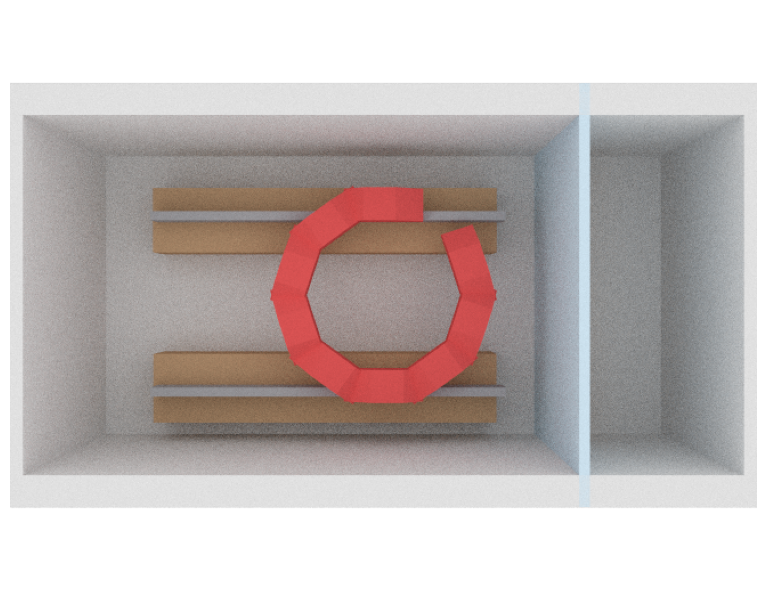

In [29]:
scene.edit(remove=[cars[-1]])

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

## Path Computation with the Edited Scene

Let's now compute radio propagation paths on the edited scene.

We start by adding a transmitter on the roof of an arbitrarily selected building, as well as a receiver on top of each car.
We also set the transmitter and receiver arrays.

In [33]:
# Add a transmitter on top of a building
scene.remove("tx")
scene.add(Transmitter("tx", position=[0, 0, 0.], display_radius=2))

# Add a receiver on top of each car
for i in range(num_cars):
    scene.remove(f"rx-{i}")
    scene.add(Receiver(f"rx-{i}", position=[cars_positions.x[i],
                                            cars_positions.y[i],
                                            cars_positions.z[i] + 3],
                      display_radius=2))


# Set the transmit and receive antenna arrays
scene.tx_array = PlanarArray(num_cols=1,
                             num_rows=1,
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

We are now ready to compute paths.

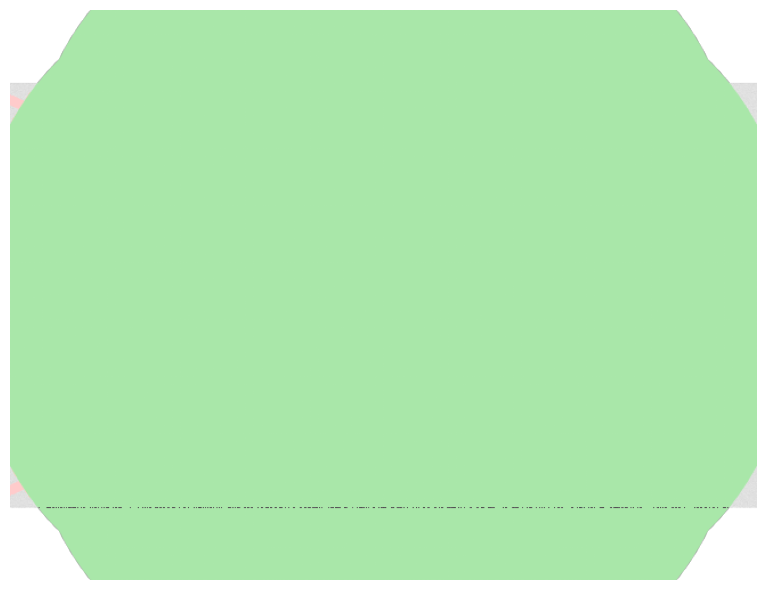

In [34]:
p_solver = PathSolver()
paths = p_solver(scene, max_depth=5)

if no_preview:
    scene.render(camera=cam, paths=paths);
else:
    scene.preview(paths=paths);

## Summary

A scene is loaded using the `load_scene()` function, which by default merges objects sharing similar properties, such as radio materials. Merging of objects can be disabled by setting the `merge_shapes` flag to `False`; however, this can incur a significant slowdown in the ray tracing process. Alternatively, specific objects can be removed from the merging process using the `merge_shapes_exclude_regex` parameter.

Scene objects can be instantiated from meshes and added to a scene using `Scene.edit()`. This function can also be used to remove objects from a scene. Note that to optimize performance and reduce processing time, it is recommended to use a single call to this function with a list of objects to add and/or remove, rather than making multiple individual calls to edit scene objects.